# Análisis de la Temperatura — Simulación de Dinámica Molecular

**Sistema:** Tripéptido **ACE-ALA-ARG-VAL-NME** (ARV) en solución acuosa  
**Campo de fuerzas:** CHARMM27 · **Modelo de agua:** TIP3P  
**Herramienta:** GROMACS · `gmx traj -ot`  
**Temperaturas simuladas:** 298 K y 400 K

Se analiza la evolución temporal de la temperatura instantánea del sistema
a las dos temperaturas de simulación (298 K y 400 K).

---

## 1. Importación de librerías y configuración de estilo

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import sem, norm

# ── Estilo publicación científica ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':         'serif',
    'font.size':           11,
    'axes.labelsize':      12,
    'axes.titlesize':      12,
    'axes.linewidth':      1.2,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.width':   1.1,
    'ytick.major.width':   1.1,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.framealpha':   0.9,
    'legend.fontsize':     10,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
})

COLS = ['time_ps', 'T_K']

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de datos

In [11]:
def load_xvg(filepath, col_names):
    """Lee un archivo .xvg de GROMACS ignorando cabeceras (líneas con '@' o '#')."""
    data = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if line.startswith('#') or line.startswith('@') or not line:
                continue
            data.append(list(map(float, line.split())))
    df = pd.DataFrame(data, columns=col_names)
    return df

df_298 = load_xvg('temp-298.xvg', COLS)
df_400 = load_xvg('temp-400.xvg', COLS)

print(f'298 K → {len(df_298)} frames  |  tiempo: {df_298.time_ps.min():.3f} – {df_298.time_ps.max():.3f} ps')
print(f'400 K → {len(df_400)} frames  |  tiempo: {df_400.time_ps.min():.3f} – {df_400.time_ps.max():.3f} ps')
df_298.head(3)

298 K → 2001 frames  |  tiempo: 0.000 – 2.000 ps
400 K → 2001 frames  |  tiempo: 0.000 – 2.000 ps


,time_ps,T_K
0,0.000,294.825
1,0.001,294.181
2,0.002,294.035


## 3. Comparativa apilada — 298 K vs 400 K

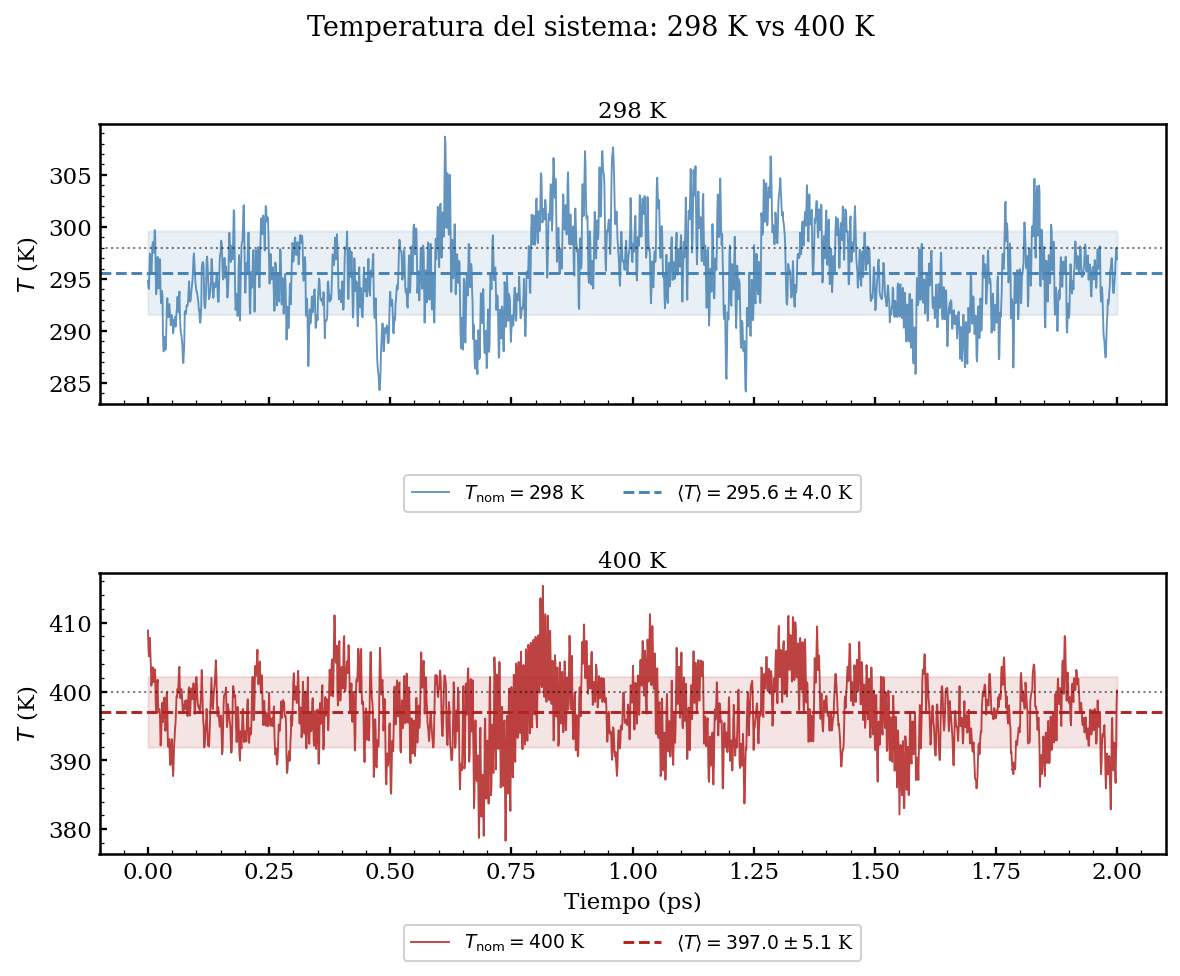

Figura guardada como temp_comparison_stacked.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)

for ax, df, T_nom, col in zip(axes,
                               [df_298, df_400],
                               [298, 400],
                               ['steelblue', 'firebrick']):
    mean_val = df['T_K'].mean()
    std_val  = df['T_K'].std()

    ax.plot(df['time_ps'], df['T_K'], color=col, lw=0.9, alpha=0.85,
            label=rf'$T_{{\mathrm{{nom}}}} = {T_nom}$ K')
    ax.axhline(mean_val, color=col, lw=1.4, ls='--',
               label=rf'$\langle T \rangle = {mean_val:.1f} \pm {std_val:.1f}$ K')
    ax.fill_between(df['time_ps'],
                    mean_val - std_val, mean_val + std_val,
                    color=col, alpha=0.12)
    ax.axhline(T_nom, color='black', lw=1.0, ls=':', alpha=0.5)

    ax.set_ylabel('$T$ (K)', fontsize=11)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.set_title(f'{T_nom} K', fontsize=11, pad=3)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9)

axes[-1].set_xlabel('Tiempo (ps)', fontsize=11)
fig.suptitle('Temperatura del sistema: 298 K vs 400 K', fontsize=13, y=1.01)
fig.align_ylabels()

plt.tight_layout()
plt.savefig('temp_comparison_stacked.png')
plt.show()
print('Figura guardada como temp_comparison_stacked.png')

## 4. Comparativa superpuesta

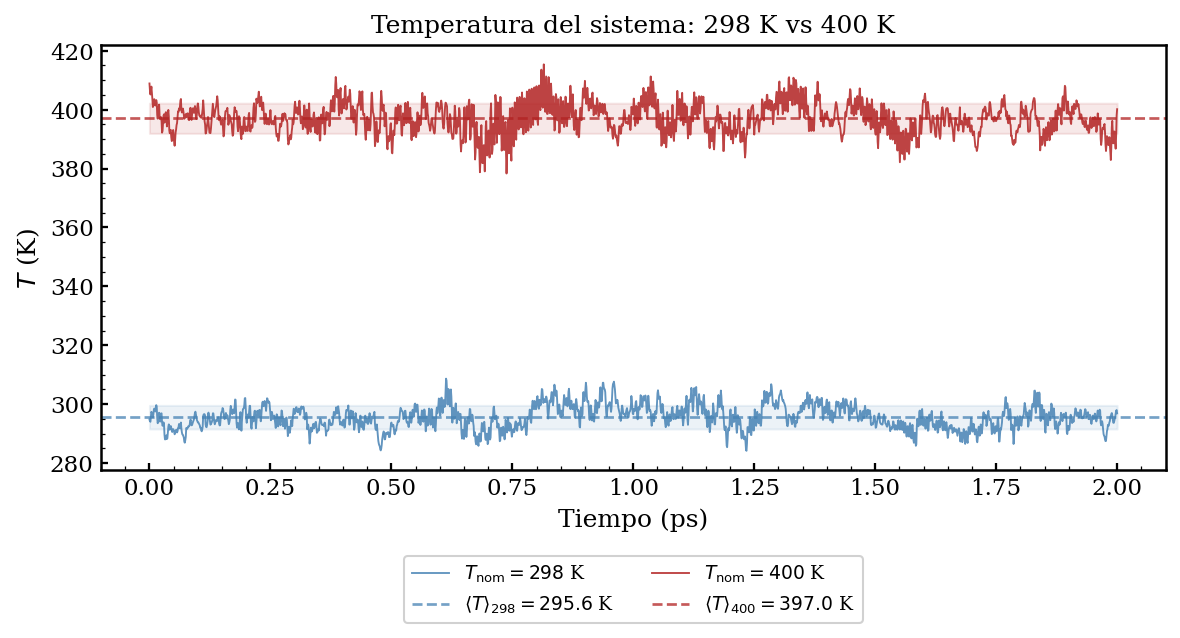

Figura guardada como temp_comparison_overlay.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for df, T_nom, col in [(df_298, 298, 'steelblue'),
                        (df_400, 400, 'firebrick')]:
    mean_val = df['T_K'].mean()
    std_val  = df['T_K'].std()

    ax.plot(df['time_ps'], df['T_K'], color=col, lw=0.9, alpha=0.85,
            label=rf'$T_{{\mathrm{{nom}}}} = {T_nom}$ K')
    ax.axhline(mean_val, color=col, lw=1.3, ls='--', alpha=0.75,
               label=rf'$\langle T \rangle_{{{T_nom}}} = {mean_val:.1f}$ K')
    ax.fill_between(df['time_ps'],
                    mean_val - std_val, mean_val + std_val,
                    color=col, alpha=0.10)

ax.set_xlabel('Tiempo (ps)')
ax.set_ylabel('$T$ (K)')
ax.set_title('Temperatura del sistema: 298 K vs 400 K')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig('temp_comparison_overlay.png')
plt.show()
print('Figura guardada como temp_comparison_overlay.png')

## 5. Histograma de temperatura

Distribución de la temperatura instantánea con ajuste gaussiano superpuesto.

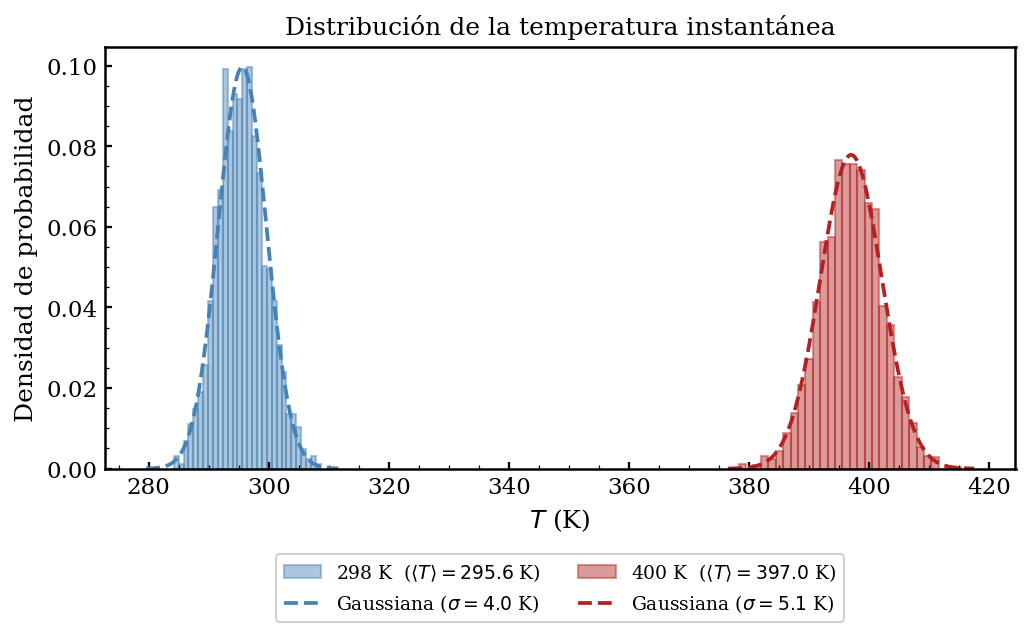

Figura guardada como temp_histogram.png


In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for df, T_nom, col in [(df_298, 298, 'steelblue'),
                        (df_400, 400, 'firebrick')]:
    mu  = df['T_K'].mean()
    sig = df['T_K'].std()

    ax.hist(df['T_K'], bins=30, density=True,
            color=col, alpha=0.45, edgecolor=col, linewidth=1.0,
            label=rf'{T_nom} K  ($\langle T \rangle = {mu:.1f}$ K)')

    x_fit = np.linspace(mu - 4*sig, mu + 4*sig, 200)
    ax.plot(x_fit, norm.pdf(x_fit, mu, sig),
            color=col, lw=1.8, ls='--',
            label=rf'Gaussiana ($\sigma = {sig:.1f}$ K)')

ax.set_xlabel('$T$ (K)')
ax.set_ylabel('Densidad de probabilidad')
ax.set_title('Distribución de la temperatura instantánea')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig('temp_histogram.png')
plt.show()
print('Figura guardada como temp_histogram.png')

## 6. Resumen estadístico completo

In [15]:
final_rows = []
for df, T_nom in [(df_298, 298), (df_400, 400)]:
    T = df['T_K']
    final_rows.append({
        'T nominal (K)':  T_nom,
        '⟨T⟩ (K)':       round(T.mean(), 2),
        'σ(T) (K)':       round(T.std(),  2),
        'SEM (K)':        round(sem(T),    3),
        'Min (K)':        round(T.min(),   2),
        'Max (K)':        round(T.max(),   2),
        'Δ⟨T⟩ (K)':      round(T.mean() - T_nom, 2),
    })

final_df = pd.DataFrame(final_rows)

(final_df.style
    .format({
        '⟨T⟩ (K)':   '{:.2f}',
        'σ(T) (K)':   '{:.2f}',
        'SEM (K)':    '{:.3f}',
        'Min (K)':    '{:.2f}',
        'Max (K)':    '{:.2f}',
        'Δ⟨T⟩ (K)':  '{:.2f}',
    })
    .set_caption('Tabla 1. Resumen estadístico de la temperatura del sistema a 298 K y 400 K.')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('margin-bottom', '6px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('text-align', 'center'), ('padding', '6px 10px'),
                   ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '5px 10px'),
                   ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#d6e4f0')]},
    ])
    .apply(lambda col: [
        'background-color: #eaf4fb' if v == 298 else 'background-color: #fdecea'
        for v in col
    ], subset=['T nominal (K)'])
    .hide(axis='index')
)

T nominal (K),⟨T⟩ (K),σ(T) (K),SEM (K),Min (K),Max (K),Δ⟨T⟩ (K)
298,295.59,4.01,0.090,284.17,308.68,-2.41
400,397.05,5.12,0.115,378.31,415.36,-2.95
